In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
model_results = pd.read_csv(
    "../model/model_comparison.csv"
)

tuned_results = pd.read_csv(
    "../model/tuned_xgb_results.csv"
)

final_results = pd.concat(
    [model_results, tuned_results],
    ignore_index=True
)

final_results.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2
3,XGBoost,530.975835,3902.367071,0.967192
4,Tuned XGBoost,5911.768552,13870.593023,0.585512
2,Random Forest (Top 20 Features),6117.023600,14434.001300,0.551156
1,Random Forest (All Features),6063.720405,14474.880927,0.548610
0,Linear Regression,8186.066088,16362.694503,0.423191


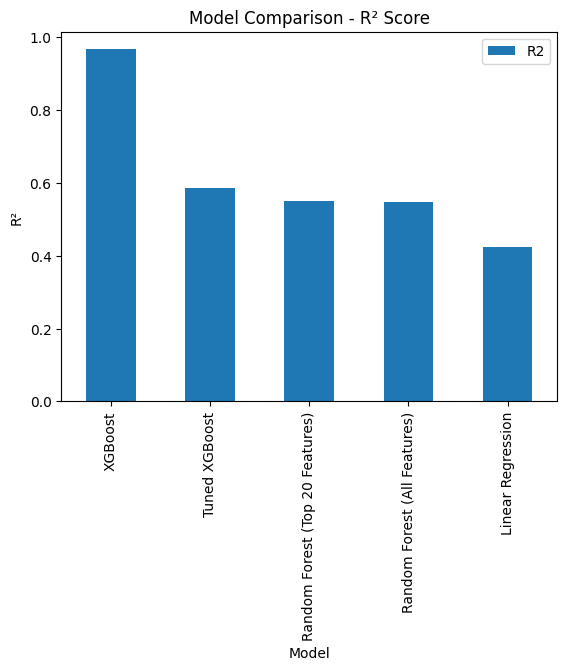

In [3]:
final_results.sort_values(
    by='R2',
    ascending=False
).plot(
    x='Model',
    y='R2',
    kind='bar'
)

plt.title('Model Comparison - R² Score')
plt.ylabel('R²')
plt.show()

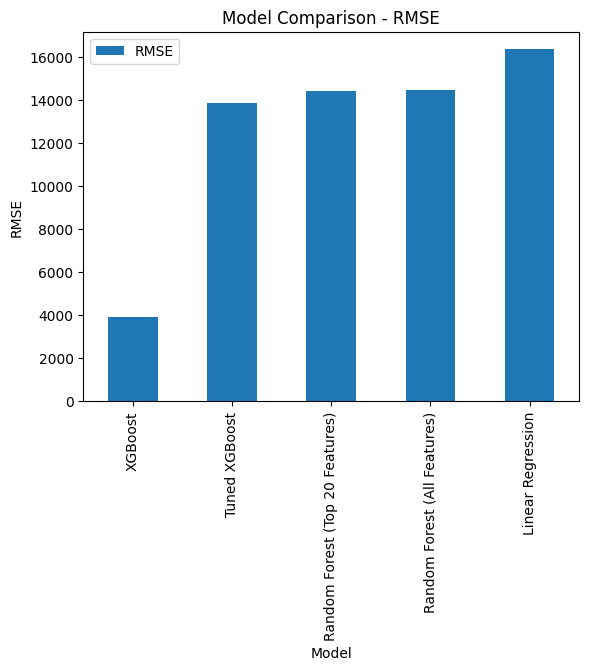

In [4]:
final_results.sort_values(
    by='RMSE'
).plot(
    x='Model',
    y='RMSE',
    kind='bar'
)

plt.title('Model Comparison - RMSE')
plt.ylabel('RMSE')
plt.show()

In [5]:
df = pd.read_csv(
    "../data/processed/campaign_data_feature_engineered.csv"
)

In [6]:
drop_cols = [
    'revenue',
    'profit',
    'revenue_per_click',
    'revenue_per_conversion',
    'profit_margin'
]

df = df.drop(columns=drop_cols)

In [7]:
X = df.drop('roi', axis=1)
y = df['roi']

In [8]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [9]:
import joblib

selected_features = joblib.load(
    "../model/model_features.pkl"
)

X = X[selected_features]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [11]:
import joblib
# Load the saved Tuned XGBoost model
best_model = joblib.load("../model/tuned_xgb_roi.pkl")

In [12]:
y_pred = best_model.predict(X_test)

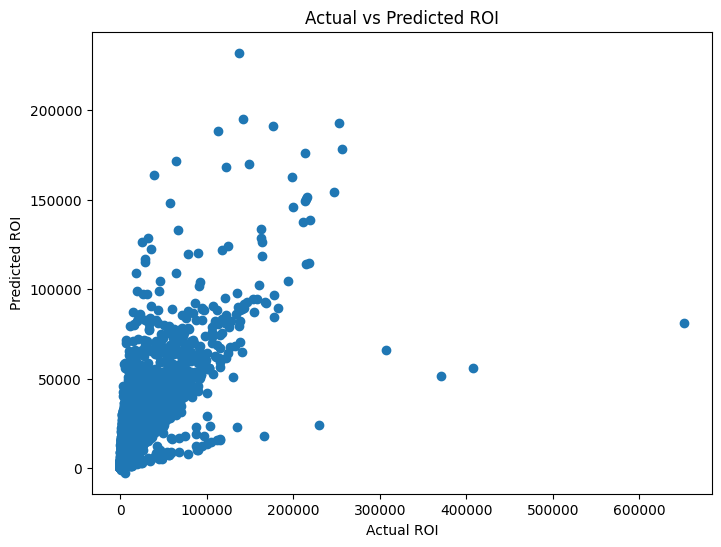

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual ROI")
plt.ylabel("Predicted ROI")

plt.title("Actual vs Predicted ROI")

plt.show()

In [14]:
residuals = y_test - y_pred

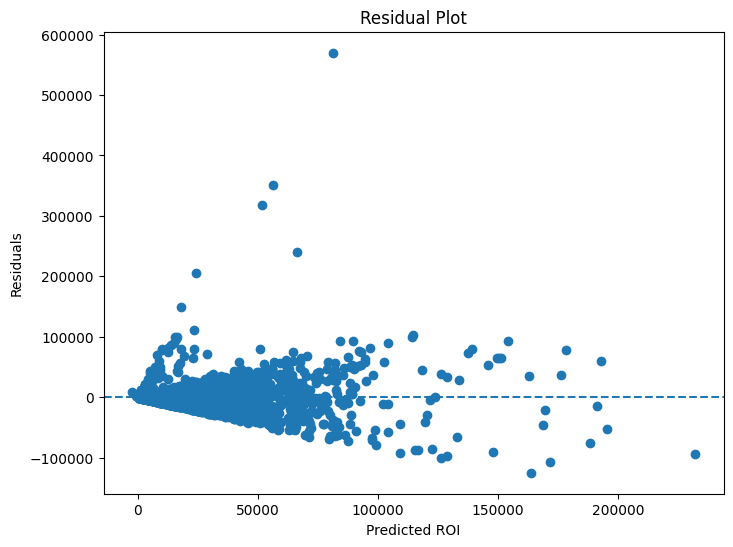

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted ROI")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

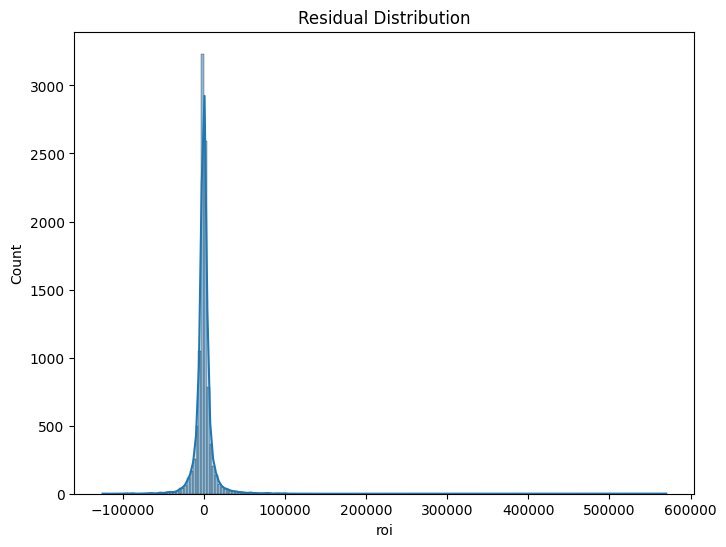

In [16]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    "Residual Distribution"
)

plt.show()

In [20]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 5911.7686
RMSE : 13870.5930
R²   : 0.5855


In [21]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
18,cpa,0.152605
17,cpl,0.074167
7,conversions,0.031636
9,spend,0.026560
14,lead_conversion_rate,0.017736
45,season_winter,0.017133
44,season_summer,0.016232
13,conversion_rate,0.016157
16,cpc,0.015413
41,age_group_45-54,0.015215


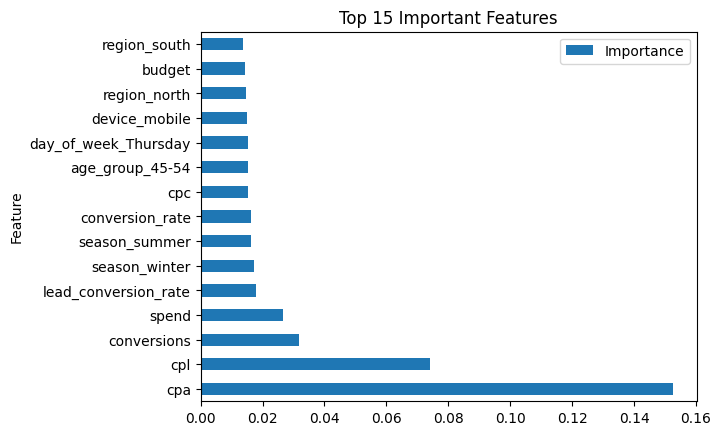

In [22]:
feature_importance.head(15).plot(
    x='Feature',
    y='Importance',
    kind='barh'
)

plt.title(
    "Top 15 Important Features"
)

plt.show()

In [23]:
print("="*50)
print("FINAL MODEL SUMMARY")
print("="*50)

print("Best Model : Tuned XGBoost")
print(f"MAE        : {mae:.4f}")
print(f"RMSE       : {rmse:.4f}")
print(f"R² Score   : {r2:.4f}")

print("="*50)

FINAL MODEL SUMMARY
Best Model : Tuned XGBoost
MAE        : 5911.7686
RMSE       : 13870.5930
R² Score   : 0.5855
